# **1. Perkenalan Dataset**


**Dataset:** Heart Failure Prediction Dataset

**Sumber:** [link Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

**Target:** HeartDisease (0: Normal, 1: Gagal Jantung)

**Deskripsi dataset:** dataset ini berisi 11 fitur klinis untuk memprediksi penyakit jantung dengan fitur sebagai berikut:

- Age: usia pasien (dalam tahun)
- Sex: jenis kelamin [M:laki-laki, F:perempuan]
- ChestPainType: jenis nyeri dada [TA: Angina Tipikal, ATA: Angina Atipikal, NAP: Nyeri Non-Angina, ASY: Asimptomatik]
- RestingBP: tekanan darah saat istirahat (dalam mm Hg)
- Cholesterol: kolesterol (dalam mm/dl)
- FastingBS: gula darah puasa [1: jika FastingBS > 120 mg/dl, 0: jika sebaliknya]
- RestingECG: hasil elektrokardiogram istirahat [Normal: Normal, ST: memiliki kelainan gelombang ST-T (inversi gelombang T dan/atau elevasi atau depresi ST > 0,05 mV), LVH: menunjukkan kemungkinan atau pasti hipertrofi ventrikel kiri menurut kriteria Estes]
- MaxHR: denyut jantung maksimal yang dapat dicapai [Nilai numerik antara 60 dan 202]
- ExerciseAngina: angina yang dipicu oleh olahraga [Y: Iya, N: Tidak]
- Oldpeak: oldpeak = ST [Nilai numerik yang diukur dalam depresi]
- ST_Slope: kemiringan segmen ST puncak latihan [Up: miring ke atas, Flat: datar, Down: miring ke bawah]
- HeartDisease: kelas keluaran [0: Normal, 1: Gagal Jantung]

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df = pd.read_csv('../heart_raw/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

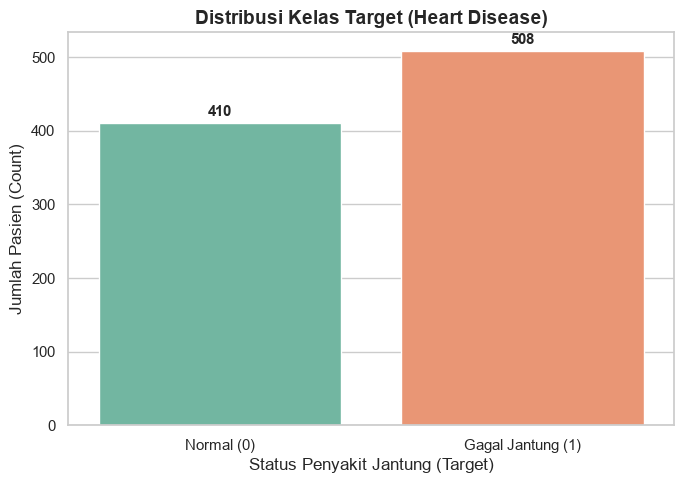

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Membuat Plot Distribusi Kelas Target (HeartDisease)
ax = sns.countplot(
    x="HeartDisease",
    data=df,
    palette="Set2",
    hue="HeartDisease",
    legend=False,
)

plt.title(
    "Distribusi Kelas Target (Heart Disease)", fontsize=14, fontweight="bold"
)
plt.xlabel("Status Penyakit Jantung (Target)", fontsize=12)
plt.ylabel("Jumlah Pasien (Count)", fontsize=12)

# Mengubah label angka pada sumbu X menjadi teks
plt.xticks(ticks=[0, 1], labels=["Normal (0)", "Gagal Jantung (1)"])

# Menambahkan Label Angka di Setiap Batang
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

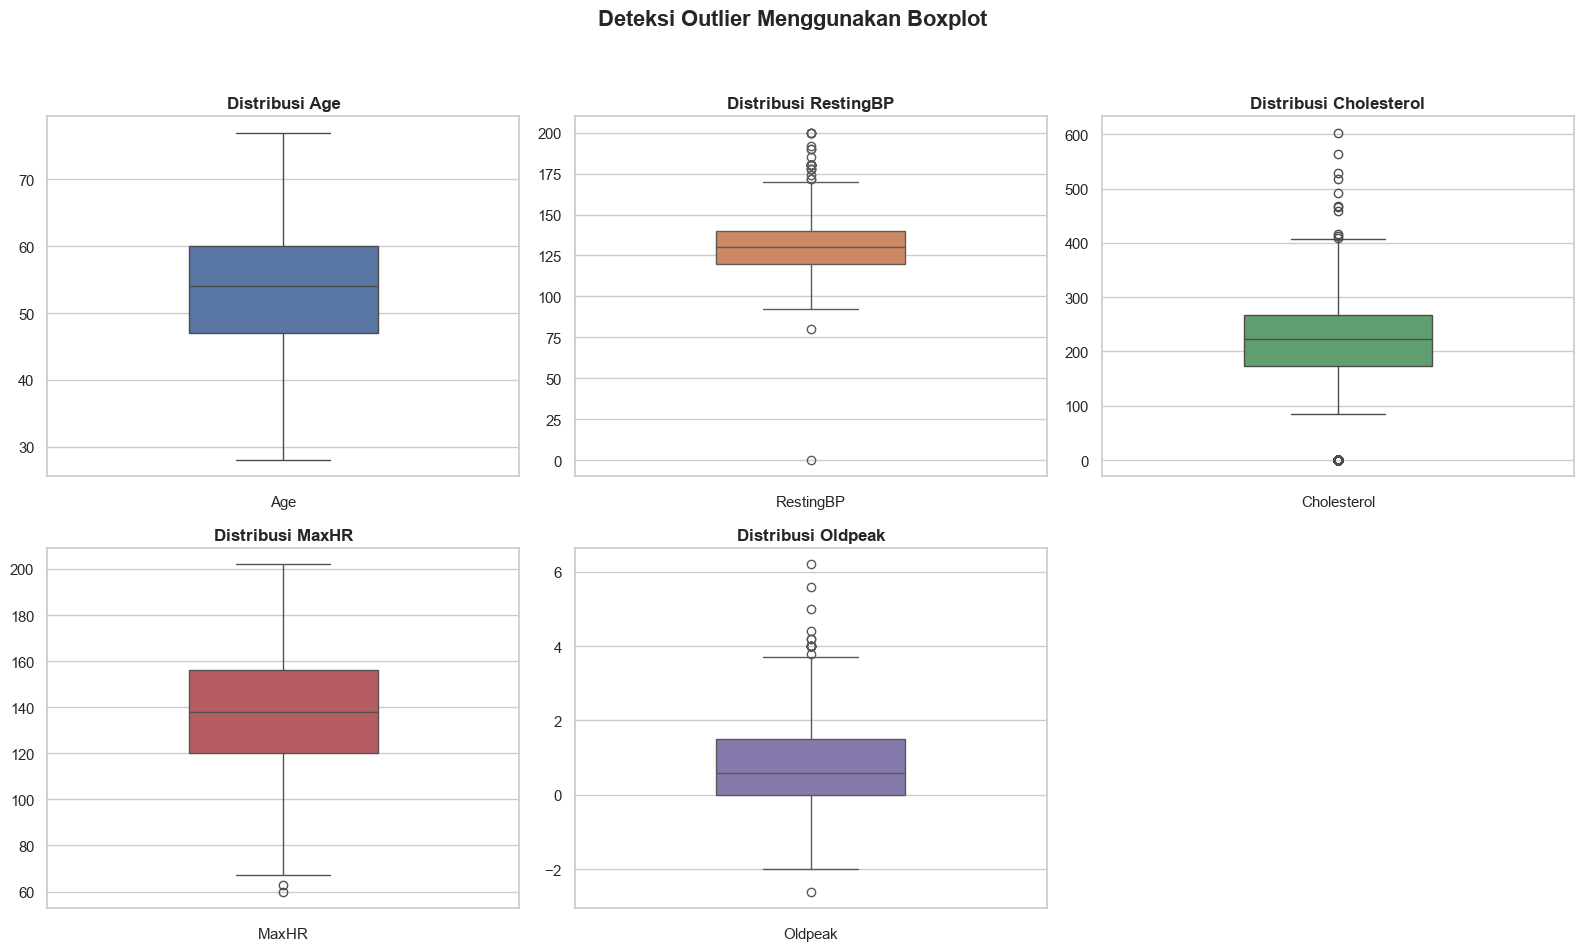

In [8]:
# fitur numerik
features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

sns.set_theme(style="whitegrid")

# Mengatur layout grid: 2 baris, 3 kolom
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Deteksi Outlier Menggunakan Boxplot",
    fontsize=16,
    fontweight="bold",
    y=0.95,
)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

# Looping untuk memasukkan boxplot ke dalam koordinat grid
for index, col in enumerate(features):
    row_idx = index // 3  # Baris 0 untuk indeks 0-2, Baris 1 untuk indeks 3-4
    col_idx = index % 3  # Kolom 0, 1, 2 secara berulang

    # Menggambar boxplot pada objek axes yang spesifik
    sns.boxplot(
        y=df[col], ax=axes[row_idx, col_idx], color=colors[index], width=0.4
    )

    # Kustomisasi judul dan label per grafik
    axes[row_idx, col_idx].set_title(
        f"Distribusi {col}", fontsize=12, fontweight="bold"
    )
    axes[row_idx, col_idx].set_ylabel("")
    axes[row_idx, col_idx].set_xlabel(col, fontsize=11)

# Menyembunyikan sisa slot grid yang kosong
axes[1, 2].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

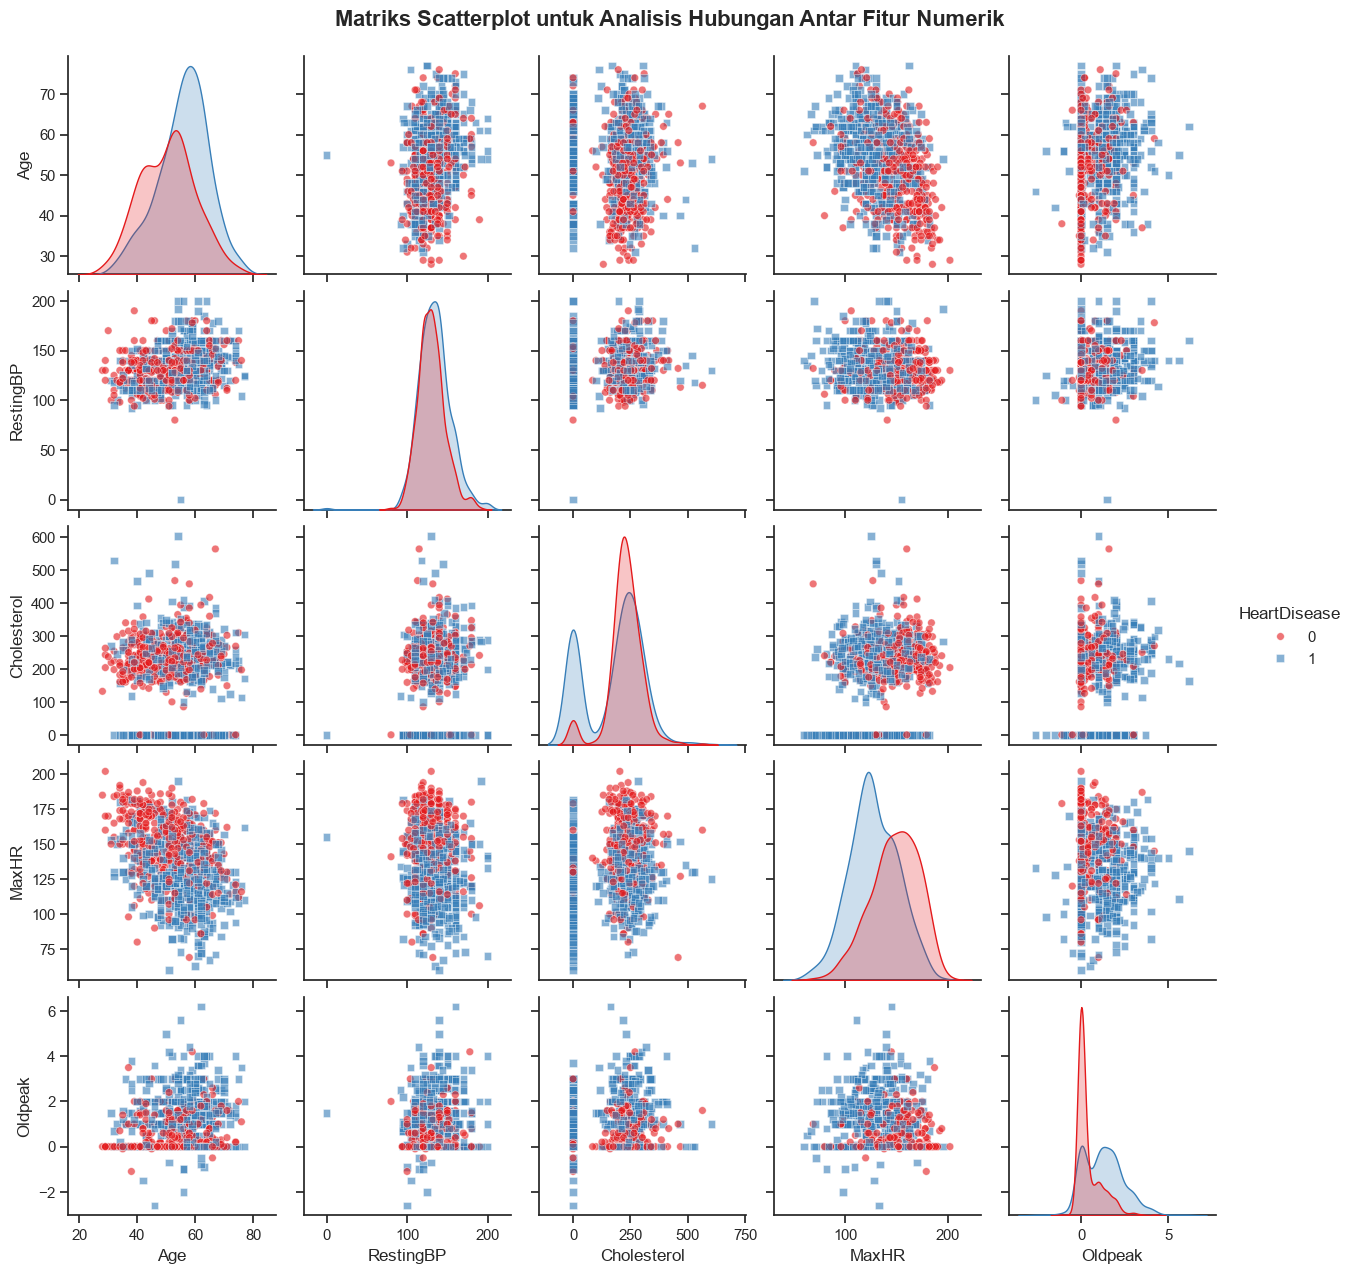

In [9]:
features_to_analyze = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "HeartDisease",
]
df_numeric = df[features_to_analyze]

# Set tema visualisasi
sns.set_theme(style="ticks")

# Membuat Pairplot (Matriks Scatterplot)
grid = sns.pairplot(
    df_numeric,
    hue="HeartDisease",
    palette="Set1",
    markers=["o", "s"],
    diag_kind="kde",  # Menampilkan grafik densitas (KDE) pada diagonal matriks
    plot_kws={"alpha": 0.6, "s": 30},  # Transparansi dan ukuran titik scatter
)

# Menambahkan judul utama pada grafik matriks
grid.fig.suptitle(
    "Matriks Scatterplot untuk Analisis Hubungan Antar Fitur Numerik",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.show()

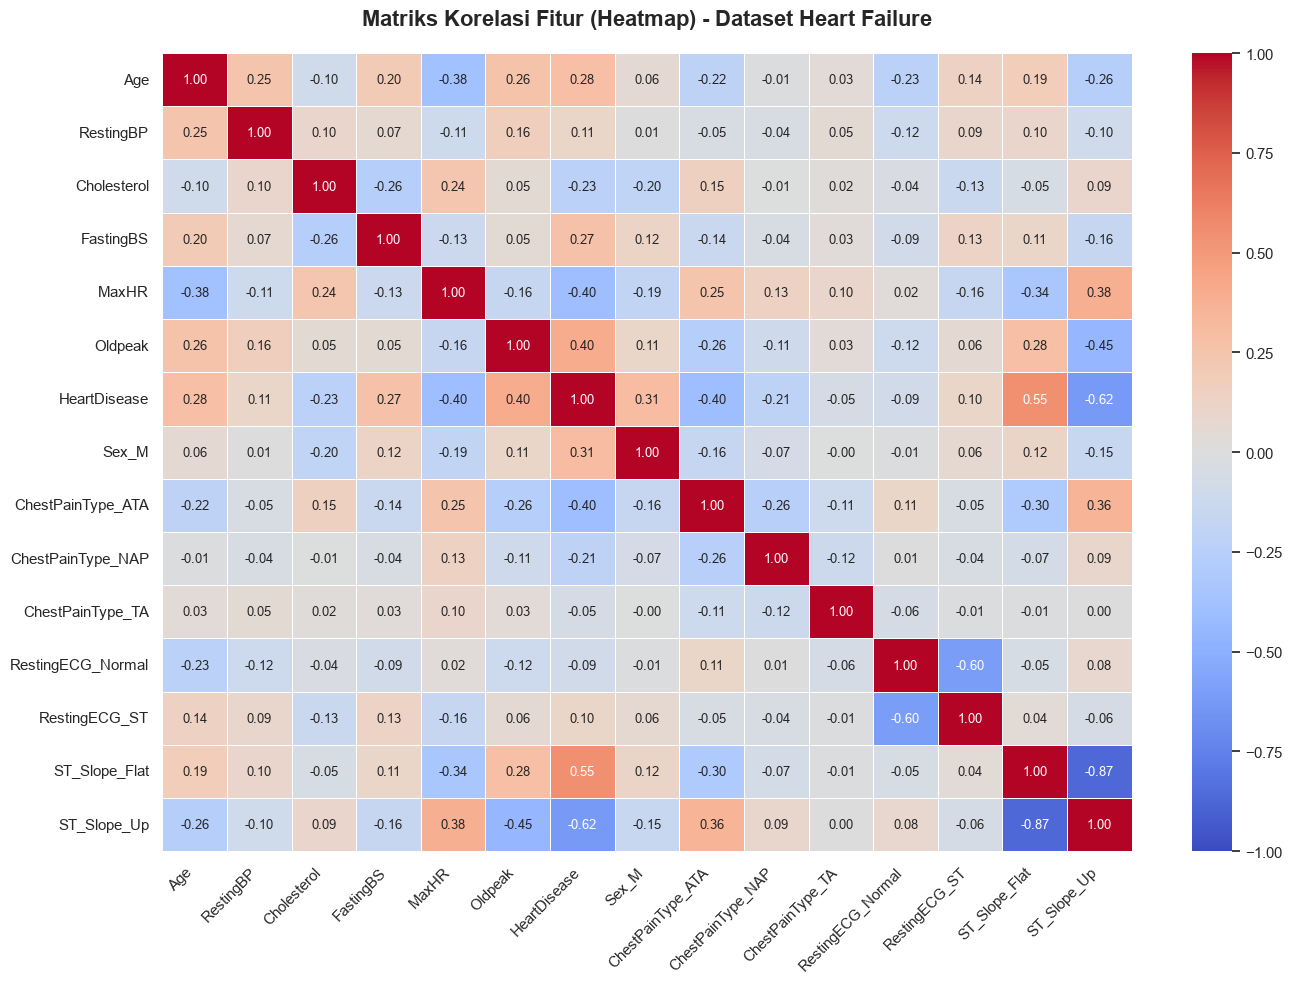

In [10]:
# Preprocessing: Mengubah fitur kategorikal (teks) menjadi numerik dengan One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=["Sex", "ChestPainType", "RestingECG", "ST_Slope"],
    drop_first=True,
)

# Tambahkan parameter numeric_only=True
correlation_matrix = df_encoded.corr(numeric_only=True)

# Mengatur area dan tema grafik Heatmap
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# Membuat Heatmap menggunakan Seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,  # Menampilkan angka nilai korelasi di dalam kotak
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 9},
    vmin=-1,
    vmax=1,  # Membatasi rentang nilai skala warna dari -1 sampai 1
)

# Kustomisasi Judul dan Tata Letak
plt.title(
    "Matriks Korelasi Fitur (Heatmap) - Dataset Heart Failure",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
df_clean = df.copy()

numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
]

# Imputasi menggunakan nilai median berdasarkan kelompok 'Sex'
for col in ["RestingBP", "Cholesterol"]:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df.groupby("Sex")[col].transform("median"))

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Menghitung jumlah outlier sebelum di-capping
    num_outliers = df_clean[
        (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    ].shape[0]

    # Melakukan Capping (mengganti nilai di luar batas ke nilai batas atas/bawah)
    df_clean[col] = np.where(
        df_clean[col] < lower_bound, lower_bound, df_clean[col]
    )
    df_clean[col] = np.where(
        df_clean[col] > upper_bound, upper_bound, df_clean[col]
    )

X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

# Membagi data untuk menangani Masalah Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Pipeline untuk fitur kontinu (Hanya Scaling)
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

# Pipeline untuk fitur kategoris (One-Hot Encoding)
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(drop="first", sparse_output=False))]
)

# Menggabungkan transformer ke ColumnTransformer
# remainder='passthrough' memastikan kolom binary_numeric_cols tidak diapa-apakan (lolos otomatis)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="passthrough",
)

# Fitting dan transformasi data melalui Pipeline resmi
X_train_res = preprocessor.fit_transform(X_train)
X_test_res = preprocessor.transform(X_test)

# Mendapatkan susunan nama kolom baru setelah One-Hot Encoding selesai
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)

# Urutan kolom final di dalam array hasil ColumnTransformer
final_column_names = numeric_cols + encoded_cat_cols + ['FastingBS']

# Mengubah kembali array training & testing menjadi DataFrame Pandas
df_train_final = pd.DataFrame(X_train_res, columns=final_column_names)
df_train_final["HeartDisease"] = y_train.values  # Memasukkan kembali target

df_test_final = pd.DataFrame(X_test_res, columns=final_column_names)
df_test_final["HeartDisease"] = y_test.values  # Memasukkan kembali target

# Menggabungkan kembali data Train dan Test menjadi satu dataset utuh hasil preprocess
df_final = pd.concat([df_train_final, df_test_final], axis=0).reset_index(drop=True)

df_final.to_csv("heart_preprocessing.csv", index=False, header=True)

In [12]:
df_final.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,FastingBS,HeartDisease
0,0.856064,-0.690179,-0.447157,-0.082596,-1.601702,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1
1,0.331343,0.482030,-0.447157,-0.629668,1.076891,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1
2,0.331343,1.068134,0.341149,-1.723811,2.033532,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1
3,1.905508,1.654238,-0.447157,-0.864127,0.694235,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,0.226399,2.240342,-0.447157,-0.512438,1.555211,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1


In [13]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    float64
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   MaxHR              918 non-null    float64
 4   Oldpeak            918 non-null    float64
 5   Sex_M              918 non-null    float64
 6   ChestPainType_ATA  918 non-null    float64
 7   ChestPainType_NAP  918 non-null    float64
 8   ChestPainType_TA   918 non-null    float64
 9   RestingECG_Normal  918 non-null    float64
 10  RestingECG_ST      918 non-null    float64
 11  ExerciseAngina_Y   918 non-null    float64
 12  ST_Slope_Flat      918 non-null    float64
 13  ST_Slope_Up        918 non-null    float64
 14  FastingBS          918 non-null    float64
 15  HeartDisease       918 non-null    int64  
dtypes: float64(15), int64(1)
m

In [14]:
df_final.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,FastingBS,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,-0.034819,0.023042,-0.027994,0.027567,0.003328,0.789760,0.188453,0.221133,0.050109,0.601307,0.193900,0.404139,0.501089,0.430283,0.233115,0.553377
std,0.989899,0.992648,1.004705,0.993797,0.986960,0.407701,0.391287,0.415236,0.218289,0.489896,0.395567,0.490992,0.500271,0.495386,0.423046,0.497414
min,-2.712042,-2.448491,-2.297488,-2.739802,-2.988831,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.718100,-0.690179,-0.556644,-0.629668,-0.836390,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.016510,-0.104075,-0.337670,0.073710,-0.262406,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,0.646176,0.482030,0.603918,0.777088,0.598571,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,2.430229,2.240342,2.344761,2.574609,2.751012,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
